In this project, we are going to exploire the different way to make a brain tumor classification with python

Loading Dataset

https://www.kaggle.com/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/data

In [ ]:
#Installation de kaggle
#!pip install -q kaggle
from google.colab import files
#files.upload()
#create a kaggle folder
!mkdir ~/.kaggle
#creation du dossier kaggle.json dans kaggle
!cp kaggle.json ~/.kaggle/
#Asking for the permission
!chmod 600 ~/.kaggle/kaggle.json


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
#Download the dataset
!kaggle datasets download mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images
!unzip mri-brain-tumor-dataset-4-class-7023-images

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: BT-MRI Dataset/BT-MRI Dataset/Training/Pituitary/BT-MRI PI Train (1331).jpg  
  inflating: BT-MRI Dataset/BT-MRI Dataset/Training/Pituitary/BT-MRI PI Train (1332).jpg  
  inflating: BT-MRI Dataset/BT-MRI Dataset/Training/Pituitary/BT-MRI PI Train (1333).jpg  
  inflating: BT-MRI Dataset/BT-MRI Dataset/Training/Pituitary/BT-MRI PI Train (1334).jpg  
  inflating: BT-MRI Dataset/BT-MRI Dataset/Training/Pituitary/BT-MRI PI Train (1335).jpg  
  inflating: BT-MRI Dataset/BT-MRI Dataset/Training/Pituitary/BT-MRI PI Train (1336).jpg  
  inflating: BT-MRI Dataset/BT-MRI Dataset/Training/Pituitary/BT-MRI PI Train (1337).jpg  
  inflating: BT-MRI Dataset/BT-MRI Dataset/Training/Pituitary/BT-MRI PI Train (1338).jpg  
  inflating: BT-MRI Dataset/BT-MRI Dataset/Training/Pituitary/BT-MRI PI Train (1339).jpg  
  inflating: BT-MRI Dataset/BT-MRI Dataset/Training/Pituitary/BT-MRI PI Train (134).jpg  
  inflating: 

# Vizualisation of the dataset

In [ ]:
import random
import os
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

In [ ]:
base_path = "/content/BT-MRI Dataset/BT-MRI Dataset/Training/"

liste_use_case = os.listdir(base_path)

In [ ]:
print(liste_use_case)

['Glioma', 'Meningioma', 'Pituitary', 'No-tumor']


Visualisation of the images

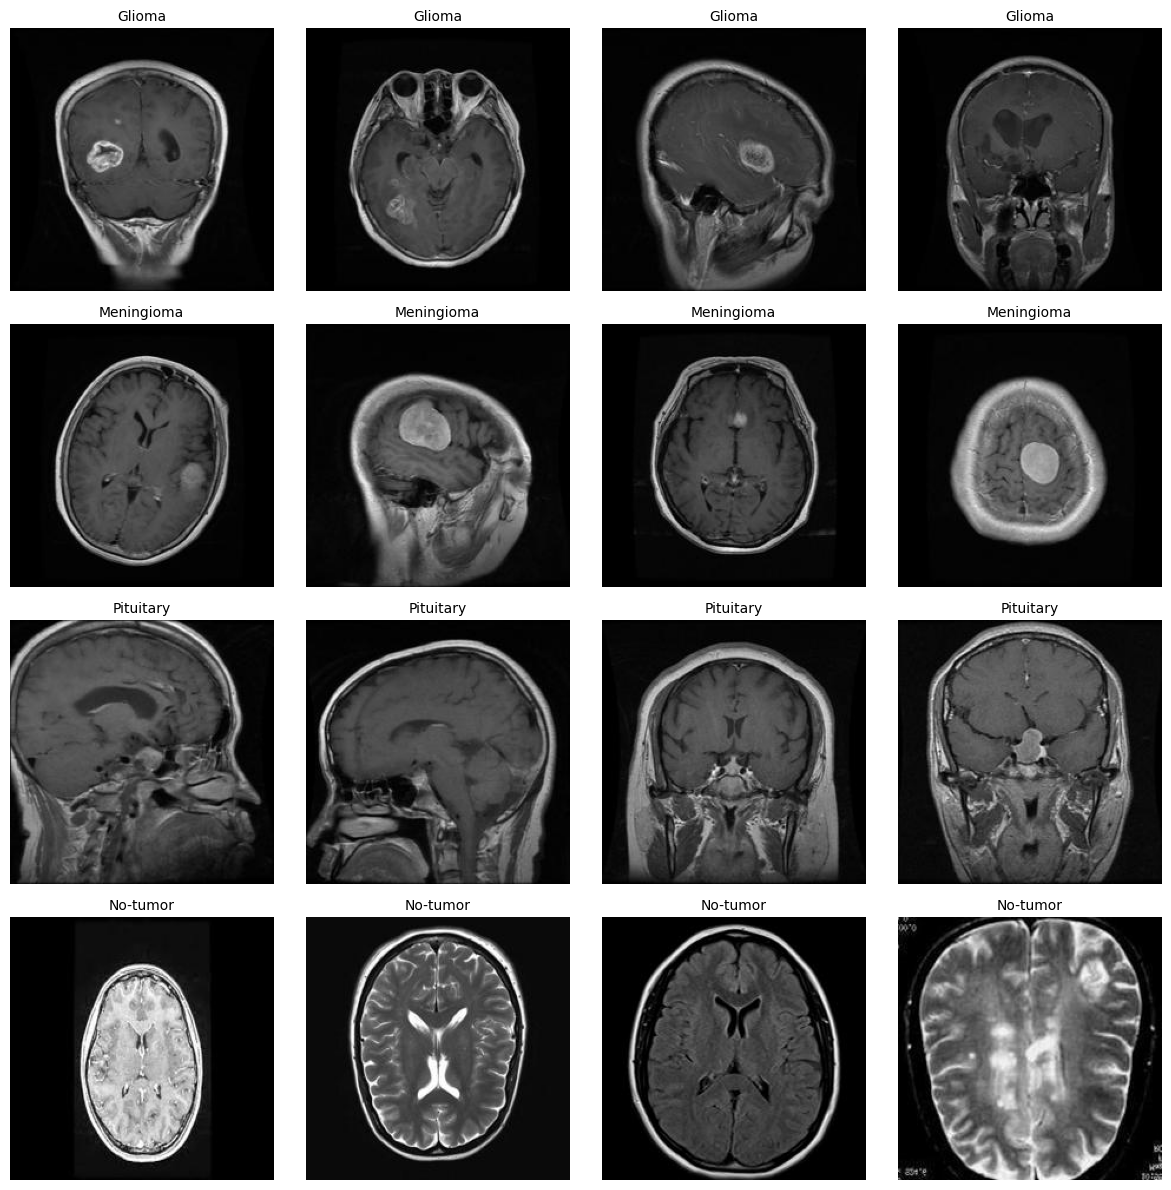

In [ ]:
images_per_class = len(liste_use_case)  # len(['Pituitary', 'Meningioma', 'No-tumor', 'Glioma'])

plt.figure(figsize=(images_per_class*3, len(liste_use_case)*3))

for i, classe in enumerate(liste_use_case):
    dossier = os.path.join(base_path, classe)

    if not os.path.isdir(dossier):
        print(f"Attention: le dossier {dossier} n'existe pas.")
        continue

    images = [f for f in os.listdir(dossier) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not images:
        print(f"Aucune image trouvée dans {dossier}.")
        continue

    selected_images = random.sample(images, min(images_per_class, len(images)))

    for j, img_name in enumerate(selected_images):
        img_path = os.path.join(dossier, img_name)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Impossible de lire l'image {img_path}.")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax = plt.subplot(len(liste_use_case), images_per_class, i*images_per_class + j + 1)
        ax.imshow(img)
        ax.axis('off')

        # titre sous l'image
        ax.set_title(classe, fontsize=10, pad=5)  # pad ajuste l'espacement sous l'image

plt.tight_layout()
plt.show()

Labels analysing

Nombre d'images par classe :
Glioma: 1321 images
Meningioma: 1339 images
Pituitary: 1457 images
No-tumor: 1595 images

Total d'images dans le dataset : 5712


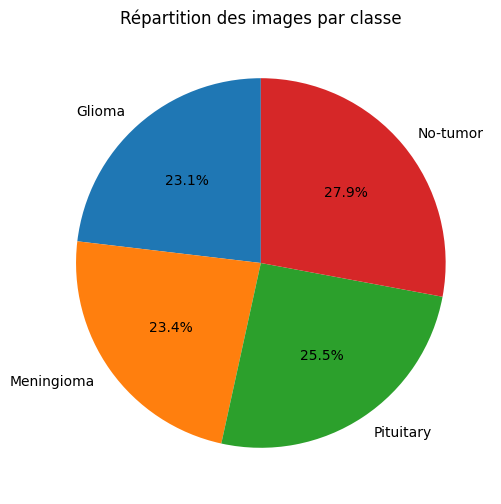

In [ ]:
import os
import matplotlib.pyplot as plt

base_path = "/content/BT-MRI Dataset/BT-MRI Dataset/Training/"
liste_use_case = os.listdir(base_path)

# compter le nombre d'images par classe
compte_images = {}
for classe in liste_use_case:
    dossier = os.path.join(base_path, classe)
    if os.path.isdir(dossier):
        images = [f for f in os.listdir(dossier) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        compte_images[classe] = len(images)

# -----------------------------
# Afficher le nombre d'images par classe
# -----------------------------
print("Nombre d'images par classe :")
for classe, nb in compte_images.items():
    print(f"{classe}: {nb} images")

# afficher le total
total_images = sum(compte_images.values())
print(f"\nTotal d'images dans le dataset : {total_images}")

# -----------------------------
# 1️⃣ Camembert
# -----------------------------
plt.figure(figsize=(6,6))
plt.pie(compte_images.values(), labels=compte_images.keys(), autopct='%1.1f%%', startangle=90)
plt.title("Répartition des images par classe")
plt.show()

image size dimension

In [ ]:
# liste pour stocker les infos
data = []

for classe in liste_use_case:
    dossier = os.path.join(base_path, classe)
    if not os.path.isdir(dossier):
        continue
    images = [f for f in os.listdir(dossier) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for img_name in images:
        img_path = os.path.join(dossier, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            h, w = img.shape[:2]
            data.append({
                "Classe": classe,
                "Nom Image": img_name,
                "Largeur": w,
                "Hauteur": h
            })

# créer un DataFrame pandas
import pandas as pd
df_dimensions = pd.DataFrame(data)

# si tu veux voir un résumé par classe
print("\nRésumé par classe :")
print(df_dimensions.groupby("Classe")[["Largeur","Hauteur"]].agg(["min","max","mean"]))


Résumé par classe :
           Largeur             Hauteur            
               min  max   mean     min  max   mean
Classe                                            
Glioma         224  224  224.0     224  224  224.0
Meningioma     224  224  224.0     224  224  224.0
No-tumor       224  224  224.0     224  224  224.0
Pituitary      224  224  224.0     224  224  224.0


#Preprocessing

In [ ]:
import scipy
from scipy import stats
import numpy as np

In [ ]:
import os
import random
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class BrainMRIDataset(Dataset):
    def __init__(self, base_path, classes, transform=None):
        self.image_paths = []
        self.labels = []
        self.transform = transform

        for idx, classe in enumerate(classes):
            dossier = os.path.join(base_path, classe)
            images = [f for f in os.listdir(dossier) if f.endswith(('.png', '.jpg', '.jpeg'))]
            for img_name in images:
                self.image_paths.append(os.path.join(dossier, img_name))
                self.labels.append(idx)

    def preprocess(self, img):
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)

        # clipping intensité
        p1, p99 = np.percentile(img, (1, 99))
        img = np.clip(img, p1, p99)

        # masque cerveau
        mask = img > 0
        mean = np.mean(img[mask])
        std = np.std(img[mask])
        img[mask] = (img[mask] - mean) / (std + 1e-8)

        # ajouter un canal pour CNN
        img = np.expand_dims(img, axis=0)
        return img

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        img = self.preprocess(img)

        if self.transform:
            img = self.transform(img)

        label = self.labels[idx]
        return torch.tensor(img, dtype=torch.float32), torch.tensor(label, dtype=torch.long)



Model trainning

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        # Bloc 1
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)

        # Bloc 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Bloc 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Fully connected
        self.fc1 = nn.Linear(128*28*28, 256)  # 224 -> 112 -> 56 -> 28
        self.fc2 = nn.Linear(256, num_classes)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 224 -> 112
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 112 -> 56
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 56 -> 28

        x = x.view(-1, 128*28*28)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
# Usage
base_path = "/content/BT-MRI Dataset/BT-MRI Dataset/Training/"
test_base_path = "/content/BT-MRI Dataset/BT-MRI Dataset/Testing/"
classes = liste_use_case  # liste de tes classes

dataset = BrainMRIDataset(base_path, classes)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

In [ ]:
from torch.utils.data import random_split

# Taille de validation (par exemple 20% du training)
val_split = 0.2
train_size = int((1 - val_split) * len(dataset))
val_size = len(dataset) - train_size

# Split aléatoire
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)


# Dataset TEST
test_dataset = BrainMRIDataset(test_base_path, classes)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
num_classes = len(classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Initialisation du modèle, optimizer et loss
model = SimpleCNN(num_classes).to(device)
#optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

# 🔹 Dictionnaire pour stocker l'historique
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

# Boucle d'entraînement
for epoch in range(12):
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    # 🔸 Validation
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)

    # Moyenne des loss et accuracy
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = correct_train / total_train
    val_acc = correct_val / total_val

    # Ajout au dictionnaire history
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1
Train Loss: 0.7488, Train Acc: 0.7612
Val Loss: 0.2970, Val Acc: 0.9003
Epoch 2
Train Loss: 0.3791, Train Acc: 0.8610
Val Loss: 0.2563, Val Acc: 0.9081
Epoch 3
Train Loss: 0.3019, Train Acc: 0.8943
Val Loss: 0.2526, Val Acc: 0.9213
Epoch 4
Train Loss: 0.2711, Train Acc: 0.9002
Val Loss: 0.1787, Val Acc: 0.9379
Epoch 5
Train Loss: 0.2203, Train Acc: 0.9188
Val Loss: 0.2062, Val Acc: 0.9239
Epoch 6
Train Loss: 0.2024, Train Acc: 0.9271
Val Loss: 0.1956, Val Acc: 0.9265
Epoch 7
Train Loss: 0.1756, Train Acc: 0.9315
Val Loss: 0.1635, Val Acc: 0.9405
Epoch 8
Train Loss: 0.1417, Train Acc: 0.9442
Val Loss: 0.1685, Val Acc: 0.9414
Epoch 9
Train Loss: 0.1295, Train Acc: 0.9508
Val Loss: 0.1618, Val Acc: 0.9449
Epoch 10
Train Loss: 0.1143, Train Acc: 0.9564
Val Loss: 0.1982, Val Acc: 0.9326
Epoch 11
Train Loss: 0.1103, Train Acc: 0.9580
Val Loss: 0.1575, Val Acc: 0.9379
Epoch 12
Train Loss: 0.1179, Train Acc: 0.9532
Val Loss: 0.1592, Val Acc: 0.9458


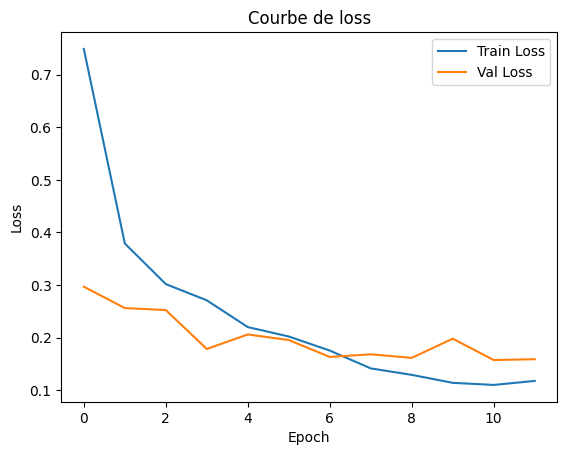

In [ ]:
#Après l'entraînement, tu peux tracer l'historique
import matplotlib.pyplot as plt

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Courbe de loss")
plt.legend()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, classes, normalize=False):
    plt.figure(figsize=(8,6))

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = ".2f"
    else:
        fmt = "d"

    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=classes,
                yticklabels=classes,
                annot_kws={"size": 14})  # taille du texte

    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("True", fontsize=12)
    plt.title("Confusion Matrix", fontsize=14)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

evaluate the model performance

In [ ]:
import torch
from sklearn.metrics import confusion_matrix

def evaluate_model(model, dataloader, device):
    """
    Évalue le modèle sur un dataloader et retourne la matrice de confusion.

    Args:
        model : le modèle PyTorch entraîné
        dataloader : DataLoader pour le jeu de test
        device : 'cuda' ou 'cpu'

    Returns:
        cm : matrice de confusion (numpy array)
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # créer la matrice de confusion
    cm = confusion_matrix(all_labels, all_preds)
    return cm

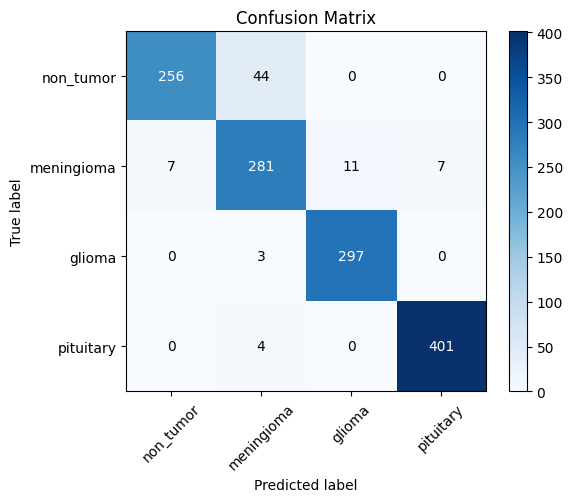

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Évaluer le modèle et récupérer la matrice de confusion
cm = evaluate_model(model, test_loader, device)

# 2️⃣ Pour afficher la matrice plus propre
classes = ["non_tumor", "meningioma", "glioma", "pituitary"]
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# 🔥 AJOUT : afficher les valeurs dans chaque case
thresh = cm.max() / 2.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

partie fine tunning

In [ ]:
base_path_BlurredDataset = '/content/Challenging Datasets/Challenging Datasets/Blurred Dataset'
base_path_NoisyDataset = '/content/Challenging Datasets/Challenging Datasets/Noisy Dataset'
base_path_Patient_Motion_Artifact_Dataset = '/content/Challenging Datasets/Challenging Datasets/Patient Motion Artifact Dataset'


In [ ]:
class BrainMRIDataset(Dataset):
    def __init__(self, base_path, classes, augment=False):
        self.image_paths = []
        self.labels = []
        self.augment = augment

        for idx, classe in enumerate(classes):
            dossier = os.path.join(base_path, classe)
            images = [f for f in os.listdir(dossier) if f.endswith(('.png', '.jpg', '.jpeg'))]

            for img_name in images:
                self.image_paths.append(os.path.join(dossier, img_name))
                self.labels.append(idx)

    def preprocess(self, img):
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)

        # 🔥 AUGMENTATION UNIQUEMENT TRAIN
        if self.augment:
            if random.random() > 0.5:
                img = cv2.GaussianBlur(img, (5,5), 0)

            if random.random() > 0.5:
                noise = np.random.normal(0, 5, img.shape)
                img = img + noise

        # ✅ NORMALISATION
        p1, p99 = np.percentile(img, (1, 99))
        img = np.clip(img, p1, p99)

        mask = img > 0
        mean = np.mean(img[mask])
        std = np.std(img[mask])
        img[mask] = (img[mask] - mean) / (std + 1e-8)

        img = img / 255.0
        img = np.expand_dims(img, axis=0)

        return img

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = self.preprocess(img)
        label = self.labels[idx]

        return torch.tensor(img, dtype=torch.float32), torch.tensor(label)

    def __len__(self):
        return len(self.image_paths)

In [ ]:
class BrainMRITestDataset(Dataset):
    def __init__(self, base_path, classes):
        self.image_paths = []
        self.labels = []

        for idx, classe in enumerate(classes):
            dossier = os.path.join(base_path, classe)
            if not os.path.isdir(dossier):
                continue

            images = [f for f in os.listdir(dossier) if f.endswith(('.png', '.jpg', '.jpeg'))]
            for img_name in images:
                self.image_paths.append(os.path.join(dossier, img_name))
                self.labels.append(idx)

    def preprocess(self, img):
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)

        p1, p99 = np.percentile(img, (1, 99))
        img = np.clip(img, p1, p99)

        mask = img > 0
        mean = np.mean(img[mask])
        std = np.std(img[mask])
        img[mask] = (img[mask] - mean) / (std + 1e-8)

        img = img / 255.0
        img = np.expand_dims(img, axis=0)

        return img

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = self.preprocess(img)
        label = self.labels[idx]

        return torch.tensor(img, dtype=torch.float32), torch.tensor(label)

    def __len__(self):
        return len(self.image_paths)

In [ ]:
classes = sorted(os.listdir(base_path))
print(classes)

['Glioma', 'Meningioma', 'No-tumor', 'Pituitary']


In [ ]:
# 🔥 TRAIN avec augmentation
train_dataset = BrainMRIDataset(base_path, classes, augment=True)

# ❌ VALIDATION sans augmentation
val_dataset = BrainMRIDataset(base_path, classes, augment=False)

# ❌ DATASETS DÉGRADÉS sans augmentation
blur_dataset = BrainMRITestDataset(base_path_BlurredDataset, classes)
noise_dataset = BrainMRITestDataset(base_path_NoisyDataset, classes)
motion_dataset = BrainMRITestDataset(base_path_Patient_Motion_Artifact_Dataset, classes)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

blur_loader = DataLoader(blur_dataset, batch_size=16, shuffle=False)
noise_loader = DataLoader(noise_dataset, batch_size=16, shuffle=False)
motion_loader = DataLoader(motion_dataset, batch_size=16, shuffle=False)

In [ ]:
# 🔹 Créer un clone du modèle original pour le fine-tuning
model_ft = SimpleCNN(num_classes).to(device)
model_ft.load_state_dict(model.state_dict())  # copie des poids du modèle original

# 🔹 Optimizer attaché au modèle fine-tuné
optimizer = torch.optim.Adam(model_ft.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# 🔹 Dictionnaire pour suivre loss et accuracy
history_ft = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# 🔹 Fine-tuning
for epoch in range(20):
    model_ft.train()
    train_loss = 0
    correct_train = 0
    total_train = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_ft(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    # Moyennes
    avg_train_loss = train_loss / len(train_loader)
    train_acc = correct_train / total_train

    # 🔹 Validation
    model_ft.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model_ft(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct_val / total_val

    # 🔹 Stocker dans l’historique
    history_ft["train_loss"].append(avg_train_loss)
    history_ft["train_acc"].append(train_acc)
    history_ft["val_loss"].append(avg_val_loss)
    history_ft["val_acc"].append(val_acc)

    print(f"Fine-tuning Epoch {epoch+1}")
    print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")

Fine-tuning Epoch 1
Train Loss: 0.9393, Train Acc: 0.5473
Val Loss: 0.5912, Val Acc: 0.8857
Fine-tuning Epoch 2
Train Loss: 0.7632, Train Acc: 0.6805
Val Loss: 0.4232, Val Acc: 0.8958
Fine-tuning Epoch 3
Train Loss: 0.6678, Train Acc: 0.7138
Val Loss: 0.3433, Val Acc: 0.9214
Fine-tuning Epoch 4
Train Loss: 0.6157, Train Acc: 0.7276
Val Loss: 0.2610, Val Acc: 0.9403
Fine-tuning Epoch 5
Train Loss: 0.5526, Train Acc: 0.7509
Val Loss: 0.2242, Val Acc: 0.9400
Fine-tuning Epoch 6
Train Loss: 0.4832, Train Acc: 0.7819
Val Loss: 0.1441, Val Acc: 0.9583
Fine-tuning Epoch 7
Train Loss: 0.4519, Train Acc: 0.7931
Val Loss: 0.1529, Val Acc: 0.9438
Fine-tuning Epoch 8
Train Loss: 0.4029, Train Acc: 0.8421
Val Loss: 0.1324, Val Acc: 0.9564
Fine-tuning Epoch 9
Train Loss: 0.3708, Train Acc: 0.8650
Val Loss: 0.2159, Val Acc: 0.9221
Fine-tuning Epoch 10
Train Loss: 0.3595, Train Acc: 0.8682
Val Loss: 0.0981, Val Acc: 0.9610
Fine-tuning Epoch 11
Train Loss: 0.3420, Train Acc: 0.8741
Val Loss: 0.1104, Va

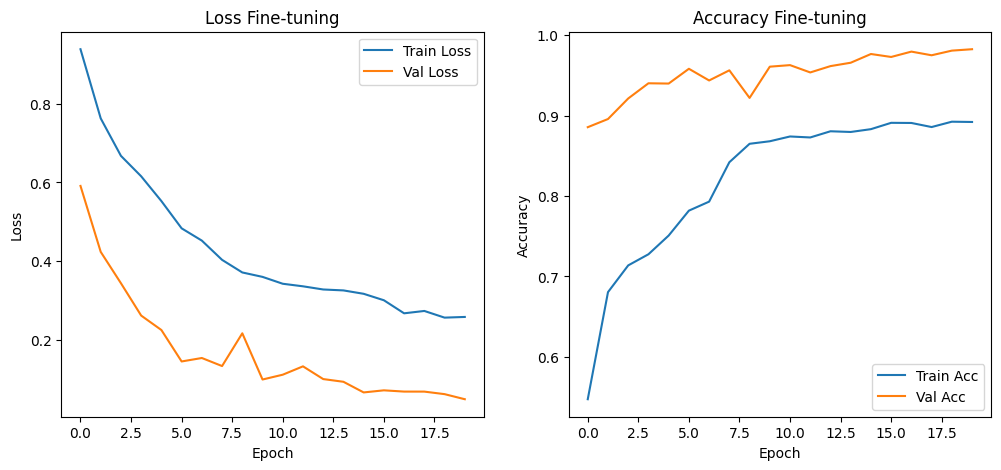

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_ft["train_loss"], label="Train Loss")
plt.plot(history_ft["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Fine-tuning")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_ft["train_acc"], label="Train Acc")
plt.plot(history_ft["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Fine-tuning")
plt.legend()

plt.show()


📊 Dataset: Blurred
Accuracy: 0.9833


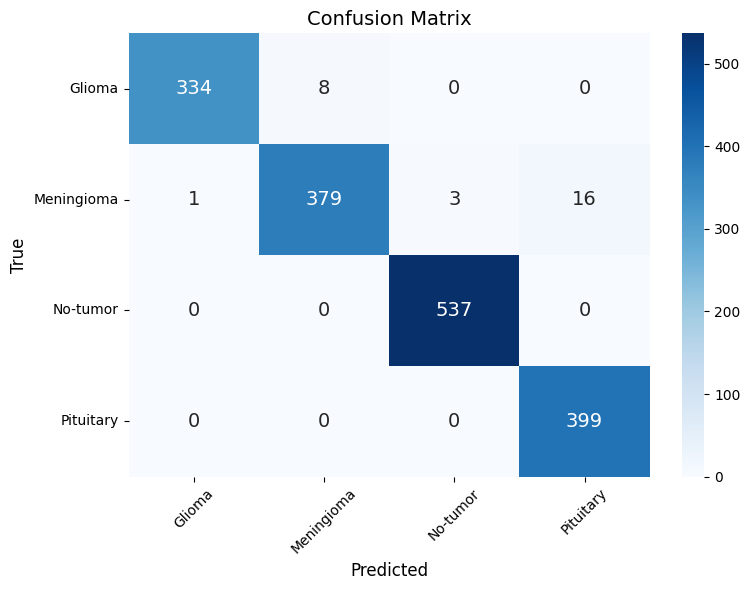


📊 Dataset: Noisy
Accuracy: 0.8038


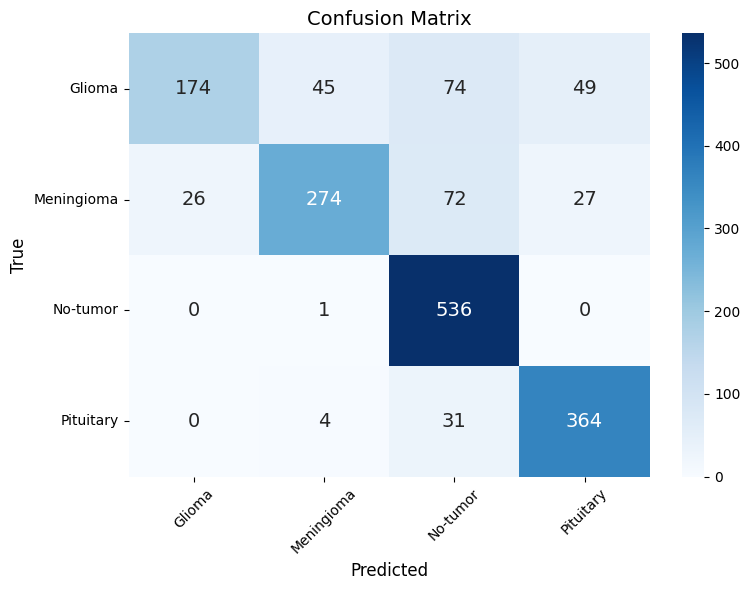


📊 Dataset: Motion
Accuracy: 0.9392


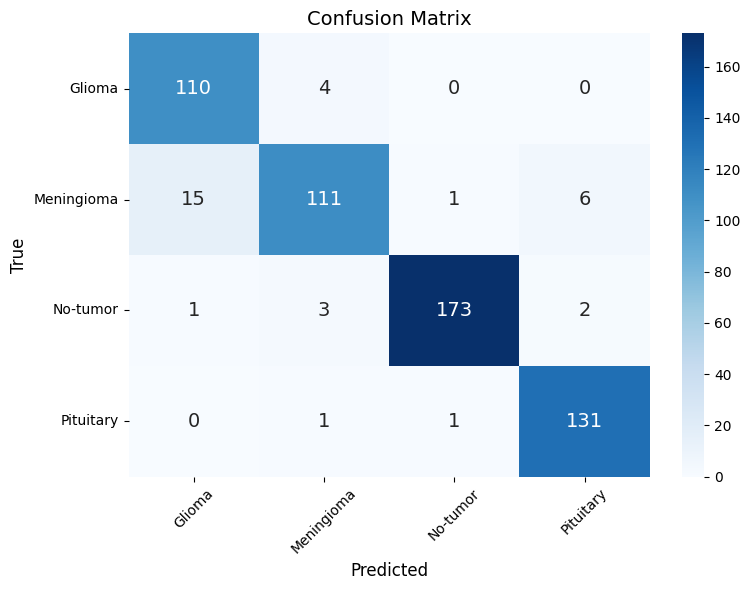

In [ ]:
def test_on_dataset(name, loader):
    cm = evaluate_model(model_ft, loader, device)
    acc = np.trace(cm) / np.sum(cm)

    print(f"\n📊 Dataset: {name}")
    print(f"Accuracy: {acc:.4f}")

    plot_confusion_matrix(cm, classes)

# 🔥 TEST FINAL
test_on_dataset("Blurred", blur_loader)
test_on_dataset("Noisy", noise_loader)
test_on_dataset("Motion", motion_loader)

resnet

on ajoute 3️⃣ Motion blur aléatoire

In [ ]:
import os
import random
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torch.nn as nn

# ===========================
# 1️⃣ Dataset
# ===========================
class BrainMRIDataset(Dataset):
    def __init__(self, base_path, classes, augment=False):
        self.image_paths = []
        self.labels = []
        self.augment = augment

        for idx, classe in enumerate(classes):
            dossier = os.path.join(base_path, classe)
            if not os.path.isdir(dossier):
                continue
            images = [f for f in os.listdir(dossier) if f.endswith(('.png', '.jpg', '.jpeg'))]
            for img_name in images:
                self.image_paths.append(os.path.join(dossier, img_name))
                self.labels.append(idx)

    def preprocess(self, img):
      # convertir en grayscale float32
      img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)

      # 🔥 Augmentation seulement si training
      if self.augment:
          # 1️⃣ Gaussian Blur aléatoire
          if random.random() > 0.5:
              ksize = random.choice([3,5,7])
              img = cv2.GaussianBlur(img, (ksize, ksize), 0)

          # 2️⃣ Bruit gaussien aléatoire
          if random.random() > 0.5:
              sigma = random.uniform(5, 20)
              noise = np.random.normal(0, sigma, img.shape)
              img = img + noise

          # 3️⃣ Motion blur aléatoire
          if random.random() > 0.5:
              size = random.choice([3,5,7])
              kernel = np.zeros((size, size))
              kernel[int((size-1)/2), :] = np.ones(size)
              kernel = kernel / size
              img = cv2.filter2D(img, -1, kernel)

      # 🔥 normalisation robuste
      p1, p99 = np.percentile(img, (1, 99))
      img = np.clip(img, p1, p99)
      mask = img > 0
      mean = np.mean(img[mask])
      std = np.std(img[mask])
      img[mask] = (img[mask] - mean) / (std + 1e-8)
      img = img / 255.0

      # 🔥 convertir en 3 canaux pour ResNet
      img = np.stack([img, img, img], axis=0)  # shape (3, H, W)
      return img

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = self.preprocess(img)
        label = self.labels[idx]
        return torch.tensor(img, dtype=torch.float32), torch.tensor(label)

    def __len__(self):
        return len(self.image_paths)



In [ ]:
import torchvision.models as models
import torch.nn as nn

# 1️⃣ Préparer le modèle ResNet18
# ===========================


model_resnet = models.resnet18(pretrained=True)



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:

# 🔥 changer la dernière couche pour notre dataset
num_classes = len(classes)
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, num_classes)
model_resnet = model_resnet.to(device)

In [ ]:
#👉 geler tous les paramètres sauf la dernière couche pour éviter overfitting
for param in model_resnet.parameters():
    param.requires_grad = False
for param in model_resnet.fc.parameters():
    param.requires_grad = True


In [ ]:

optimizer = torch.optim.Adam(model_resnet.fc.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ===========================
# 1️⃣ Datasets dégradés
# ===========================

# 🔥 TRAIN avec augmentation
train_dataset = BrainMRIDataset(base_path, classes, augment=True)

# ❌ VALIDATION sans augmentation
val_dataset = BrainMRIDataset(base_path, classes, augment=False)

# ❌ DATASETS DÉGRADÉS sans augmentation
blur_dataset = BrainMRITestDataset(base_path_BlurredDataset, classes)
noise_dataset = BrainMRITestDataset(base_path_NoisyDataset, classes)
motion_dataset = BrainMRITestDataset(base_path_Patient_Motion_Artifact_Dataset, classes)

# ========

In [ ]:

####Loader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

blur_loader = DataLoader(blur_dataset, batch_size=16, shuffle=False)
noise_loader = DataLoader(noise_dataset, batch_size=16, shuffle=False)
motion_loader = DataLoader(motion_dataset, batch_size=16, shuffle=False)

In [ ]:
import matplotlib.pyplot as plt

# listes pour stocker les metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# 2️⃣ Entraînement avec validation
for epoch in range(50):
    # ----- TRAIN -----
    model_resnet.train()
    train_loss = 0
    correct_train = 0
    total_train = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_resnet(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_acc = correct_train / total_train
    train_losses.append(train_loss / len(train_loader))
    train_accuracies.append(train_acc)

    # ----- VALIDATION -----
    model_resnet.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model_resnet(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_acc = correct_val / total_val
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1} | "
          f"Train Loss: {train_loss/len(train_loader):.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f}, Val Acc: {val_acc:.4f}")

Epoch 1 | Train Loss: 1.2213, Train Acc: 0.4606 | Val Loss: 0.9349, Val Acc: 0.6859
Epoch 2 | Train Loss: 0.9287, Train Acc: 0.6698 | Val Loss: 0.7364, Val Acc: 0.7668
Epoch 3 | Train Loss: 0.8131, Train Acc: 0.7176 | Val Loss: 0.6519, Val Acc: 0.7903
Epoch 4 | Train Loss: 0.7527, Train Acc: 0.7332 | Val Loss: 0.5947, Val Acc: 0.8172
Epoch 5 | Train Loss: 0.7108, Train Acc: 0.7435 | Val Loss: 0.5486, Val Acc: 0.8358
Epoch 6 | Train Loss: 0.6909, Train Acc: 0.7537 | Val Loss: 0.5352, Val Acc: 0.8204
Epoch 7 | Train Loss: 0.6661, Train Acc: 0.7631 | Val Loss: 0.5027, Val Acc: 0.8342
Epoch 8 | Train Loss: 0.6391, Train Acc: 0.7703 | Val Loss: 0.4833, Val Acc: 0.8414
Epoch 9 | Train Loss: 0.6335, Train Acc: 0.7680 | Val Loss: 0.4784, Val Acc: 0.8435
Epoch 10 | Train Loss: 0.6080, Train Acc: 0.7834 | Val Loss: 0.4640, Val Acc: 0.8431
Epoch 11 | Train Loss: 0.5979, Train Acc: 0.7803 | Val Loss: 0.4683, Val Acc: 0.8316
Epoch 12 | Train Loss: 0.5935, Train Acc: 0.7880 | Val Loss: 0.4551, Val A

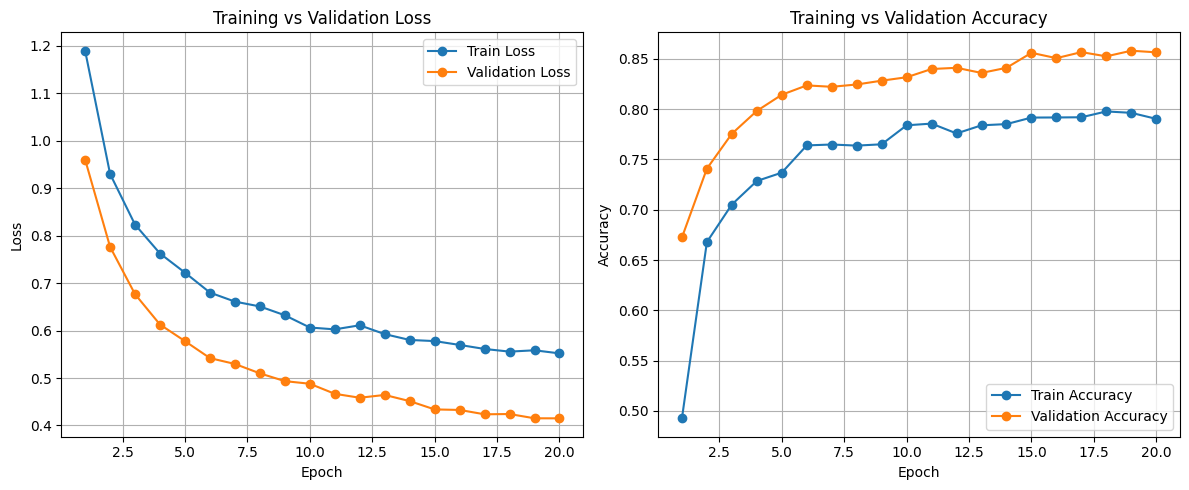

In [ ]:
# 🔹 Tracer les courbes
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss pendant l\'entraînement(avec resnet)')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy pendant l\'entraînement(avec resnet)')
plt.legend()

plt.show()


===== Blurred Dataset =====
Accuracy: 0.8515

Classification Report:
               precision    recall  f1-score   support

      Glioma       0.92      0.85      0.88       342
  Meningioma       0.74      0.77      0.76       399
    No-tumor       0.94      0.89      0.92       537
   Pituitary       0.80      0.88      0.84       399

    accuracy                           0.85      1677
   macro avg       0.85      0.85      0.85      1677
weighted avg       0.86      0.85      0.85      1677



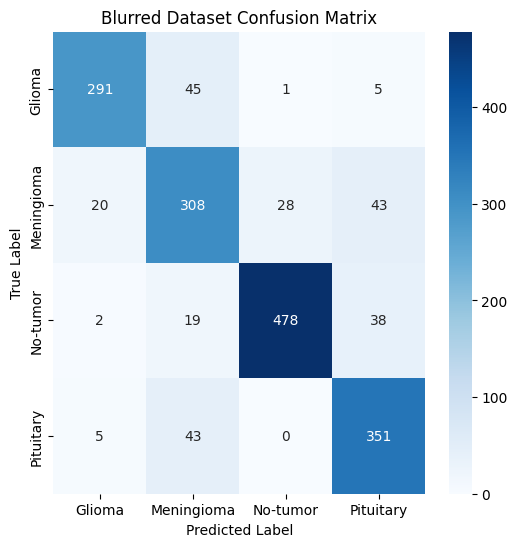


===== Noisy Dataset =====
Accuracy: 0.6386

Classification Report:
               precision    recall  f1-score   support

      Glioma       0.95      0.38      0.54       342
  Meningioma       0.73      0.46      0.57       399
    No-tumor       0.54      0.94      0.69       537
   Pituitary       0.71      0.63      0.66       399

    accuracy                           0.64      1677
   macro avg       0.73      0.60      0.62      1677
weighted avg       0.71      0.64      0.62      1677



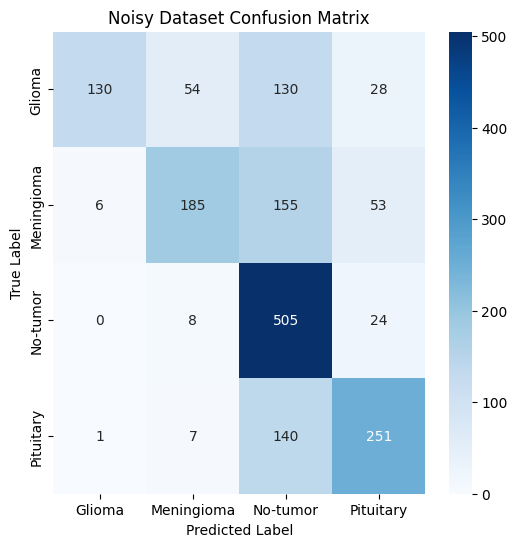


===== Motion Dataset =====
Accuracy: 0.7728

Classification Report:
               precision    recall  f1-score   support

      Glioma       0.91      0.61      0.73       114
  Meningioma       0.68      0.67      0.68       133
    No-tumor       0.78      0.94      0.85       179
   Pituitary       0.77      0.80      0.78       133

    accuracy                           0.77       559
   macro avg       0.79      0.75      0.76       559
weighted avg       0.78      0.77      0.77       559



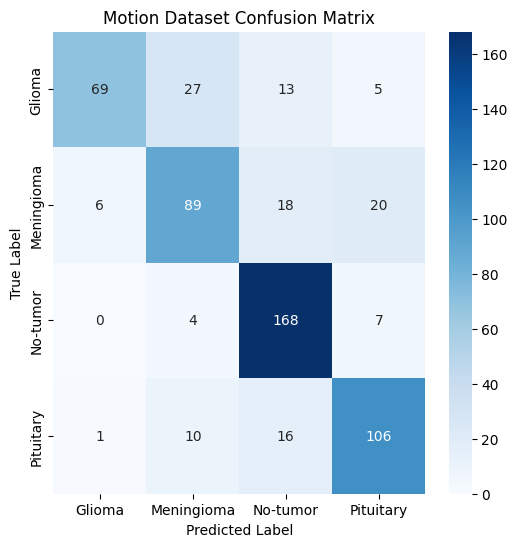

In [ ]:
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ===========================
# 2️⃣ Fonction d'évaluation Resnet
# ===========================
def evaluate_model_resnet(model, dataloader, device, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in dataloader:
            # 🔹 convertir en 3 canaux si nécessaire
            if imgs.shape[1] == 1:  # grayscale
                imgs = imgs.repeat(1, 3, 1, 1)
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # accuracy et classification report
    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=classes)

    # matrice de confusion
    cm = confusion_matrix(all_labels, all_preds)

    return acc, report, cm

# ===========================
# 4️⃣ Affichage de la confusion matrix
# ===========================
def plot_confusion_matrix(cm, classes, title='Confusion Matrix'):
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title(title)
    plt.show()

# ===========================
# 5️⃣ Evaluer tous les datasets
# ===========================
for name, loader in zip(["Blurred", "Noisy", "Motion"],
                        [blur_loader, noise_loader, motion_loader]):
    print(f"\n===== {name} Dataset =====")
    acc, report, cm = evaluate_model_resnet(model_resnet, loader, device, classes)
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:\n", report)
    plot_confusion_matrix(cm, classes, title=f"{name} Dataset Confusion Matrix")